In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path

In [2]:
df = pd.read_csv("../data/processed/dk2_merged_price_weather_energy.csv")

df["HourUTC"] = pd.to_datetime(df["HourUTC"])
df["HourDK"] = pd.to_datetime(df["HourDK"])

df = df.sort_values("HourUTC").reset_index(drop=True)

print("Rows:", len(df))
print("Date range:", df["HourUTC"].min(), "→", df["HourUTC"].max())
print("Missing values:", df.isna().sum().sum())

df.head()

Rows: 9824
Date range: 2024-08-17 06:00:00 → 2025-09-30 13:00:00
Missing values: 0


,HourUTC,HourDK,PriceArea,SpotPriceEUR,hour,day_of_week,month,year,is_weekend,price_lag_24h,...,offshore_wind_mwh,onshore_wind_mwh,solar_mwh,total_wind_mwh,renewable_generation_mwh,net_load_mwh,ExchangeSE_MWh,ExchangeGE_MWh,ExchangeGreatBelt_MWh,PowerToHeatMWh
0,2024-08-17 06:00:00,2024-08-17 08:00:00,DK2,103.430000,8,5,8,2024,1,124.830002,...,139.575607,12.631012,290.954754,152.206619,443.161373,913.084285,1004.938750,-542.164000,181.2,32.783193
1,2024-08-17 07:00:00,2024-08-17 09:00:00,DK2,84.000000,9,5,8,2024,1,100.949997,...,111.449682,14.223518,464.444211,125.673200,590.117411,897.563125,1164.431492,-839.658984,202.5,24.287895
2,2024-08-17 08:00:00,2024-08-17 10:00:00,DK2,69.489998,10,5,8,2024,1,76.150002,...,86.846481,11.792317,592.522881,98.638798,691.161679,871.185718,1220.923492,-943.107016,244.5,15.592138
3,2024-08-17 09:00:00,2024-08-17 11:00:00,DK2,54.160000,11,5,8,2024,1,59.830002,...,56.012000,14.692761,641.920324,70.704761,712.625085,884.160102,1320.748250,-959.805000,171.9,14.801758
4,2024-08-17 10:00:00,2024-08-17 12:00:00,DK2,46.830002,12,5,8,2024,1,50.680000,...,35.773500,14.832262,675.559553,50.605762,726.165315,868.566350,1008.507250,-865.089992,340.9,12.442353


In [3]:
horizon = 24

df["target_24h_ahead"] = df["SpotPriceEUR"].shift(-horizon)

df = df.dropna(subset=["target_24h_ahead"]).reset_index(drop=True)

print("Rows after target:", len(df))
print("Date range:", df["HourUTC"].min(), "→", df["HourUTC"].max())

Rows after target: 9800
Date range: 2024-08-17 06:00:00 → 2025-09-29 13:00:00


In [4]:
target_col = "target_24h_ahead"

exclude_cols = [
    "HourUTC",
    "HourDK",
    "PriceArea",
    "target_next_hour",
    "target_24h_ahead",
]

feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].select_dtypes(include=["number"])
y = df[target_col]

feature_cols = X.columns.tolist()

print("Number of features:", len(feature_cols))
feature_cols

Number of features: 32


['SpotPriceEUR',
 'hour',
 'day_of_week',
 'month',
 'year',
 'is_weekend',
 'price_lag_24h',
 'price_lag_48h',
 'price_lag_168h',
 'price_rolling_mean_24h',
 'price_rolling_std_24h',
 'price_rolling_mean_168h',
 'price_rolling_std_168h',
 'temperature_2m',
 'wind_speed_10m',
 'wind_speed_100m',
 'cloud_cover',
 'shortwave_radiation',
 'GrossConsumptionMWh',
 'CentralPowerMWh',
 'LocalPowerMWh',
 'CommercialPowerMWh',
 'offshore_wind_mwh',
 'onshore_wind_mwh',
 'solar_mwh',
 'total_wind_mwh',
 'renewable_generation_mwh',
 'net_load_mwh',
 'ExchangeSE_MWh',
 'ExchangeGE_MWh',
 'ExchangeGreatBelt_MWh',
 'PowerToHeatMWh']

In [5]:
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return mae, rmse

In [6]:
initial_train_size = 24 * 180   # 180 días iniciales de entrenamiento
test_window = 24 * 14           # predice bloques de 14 días
step_size = 24 * 14             # avanza 14 días por iteración

walk_forward_results = []
all_predictions = []

start = initial_train_size

while start + test_window <= len(df):
    train_end = start
    test_end = start + test_window

    train_df = df.iloc[:train_end].copy()
    test_df = df.iloc[train_end:test_end].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae, rmse = evaluate_forecast(y_test, y_pred)

    walk_forward_results.append({
        "train_start": train_df["HourUTC"].min(),
        "train_end": train_df["HourUTC"].max(),
        "test_start": test_df["HourUTC"].min(),
        "test_end": test_df["HourUTC"].max(),
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
    })

    fold_predictions = test_df[["HourUTC", "HourDK", "SpotPriceEUR", target_col]].copy()
    fold_predictions["pred_xgboost_24h"] = y_pred
    fold_predictions["fold"] = len(walk_forward_results)

    all_predictions.append(fold_predictions)

    print(
        f"Fold {len(walk_forward_results)} | "
        f"Test: {test_df['HourUTC'].min()} → {test_df['HourUTC'].max()} | "
        f"MAE: {mae:.2f} | RMSE: {rmse:.2f}"
    )

    start += step_size

Fold 1 | Test: 2025-02-13 06:00:00 → 2025-02-27 05:00:00 | MAE: 27.34 | RMSE: 37.14
Fold 2 | Test: 2025-02-27 06:00:00 → 2025-03-13 05:00:00 | MAE: 31.23 | RMSE: 39.50
Fold 3 | Test: 2025-03-13 06:00:00 → 2025-03-27 05:00:00 | MAE: 33.48 | RMSE: 42.39
Fold 4 | Test: 2025-03-27 06:00:00 → 2025-04-10 05:00:00 | MAE: 27.30 | RMSE: 34.78
Fold 5 | Test: 2025-04-10 06:00:00 → 2025-04-24 05:00:00 | MAE: 25.57 | RMSE: 32.07
Fold 6 | Test: 2025-04-24 06:00:00 → 2025-05-08 05:00:00 | MAE: 18.00 | RMSE: 22.60
Fold 7 | Test: 2025-05-08 06:00:00 → 2025-05-22 05:00:00 | MAE: 21.00 | RMSE: 27.03
Fold 8 | Test: 2025-05-22 06:00:00 → 2025-06-05 05:00:00 | MAE: 28.24 | RMSE: 35.37
Fold 9 | Test: 2025-06-05 06:00:00 → 2025-06-19 05:00:00 | MAE: 22.23 | RMSE: 28.77
Fold 10 | Test: 2025-06-19 06:00:00 → 2025-07-03 05:00:00 | MAE: 33.11 | RMSE: 45.70
Fold 11 | Test: 2025-07-03 06:00:00 → 2025-07-17 05:00:00 | MAE: 20.16 | RMSE: 25.11
Fold 12 | Test: 2025-07-17 06:00:00 → 2025-07-31 05:00:00 | MAE: 24.53 | R

In [7]:
walk_forward_df = pd.DataFrame(walk_forward_results)

walk_forward_df["MAE"] = walk_forward_df["MAE"].round(2)
walk_forward_df["RMSE"] = walk_forward_df["RMSE"].round(2)

walk_forward_df

,train_start,train_end,test_start,test_end,train_rows,test_rows,MAE,RMSE
0,2024-08-17 06:00:00,2025-02-13 05:00:00,2025-02-13 06:00:00,2025-02-27 05:00:00,4320,336,27.34,37.14
1,2024-08-17 06:00:00,2025-02-27 05:00:00,2025-02-27 06:00:00,2025-03-13 05:00:00,4656,336,31.23,39.50
2,2024-08-17 06:00:00,2025-03-13 05:00:00,2025-03-13 06:00:00,2025-03-27 05:00:00,4992,336,33.48,42.39
3,2024-08-17 06:00:00,2025-03-27 05:00:00,2025-03-27 06:00:00,2025-04-10 05:00:00,5328,336,27.30,34.78
4,2024-08-17 06:00:00,2025-04-10 05:00:00,2025-04-10 06:00:00,2025-04-24 05:00:00,5664,336,25.57,32.07
5,2024-08-17 06:00:00,2025-04-24 05:00:00,2025-04-24 06:00:00,2025-05-08 05:00:00,6000,336,18.00,22.60
6,2024-08-17 06:00:00,2025-05-08 05:00:00,2025-05-08 06:00:00,2025-05-22 05:00:00,6336,336,21.00,27.03
7,2024-08-17 06:00:00,2025-05-22 05:00:00,2025-05-22 06:00:00,2025-06-05 05:00:00,6672,336,28.24,35.37
8,2024-08-17 06:00:00,2025-06-05 05:00:00,2025-06-05 06:00:00,2025-06-19 05:00:00,7008,336,22.23,28.77
9,2024-08-17 06:00:00,2025-06-19 05:00:00,2025-06-19 06:00:00,2025-07-03 05:00:00,7344,336,33.11,45.70


In [8]:
print("Walk-forward average MAE:", round(walk_forward_df["MAE"].mean(), 2))
print("Walk-forward average RMSE:", round(walk_forward_df["RMSE"].mean(), 2))

print("Best fold MAE:", round(walk_forward_df["MAE"].min(), 2))
print("Worst fold MAE:", round(walk_forward_df["MAE"].max(), 2))

Walk-forward average MAE: 25.48
Walk-forward average RMSE: 33.32
Best fold MAE: 16.84
Worst fold MAE: 33.48


In [9]:
predictions_df = pd.concat(all_predictions, ignore_index=True)

predictions_df.head()

,HourUTC,HourDK,SpotPriceEUR,target_24h_ahead,pred_xgboost_24h,fold
0,2025-02-13 06:00:00,2025-02-13 07:00:00,190.330002,229.089996,151.743088,1
1,2025-02-13 07:00:00,2025-02-13 08:00:00,222.380005,265.649994,166.083969,1
2,2025-02-13 08:00:00,2025-02-13 09:00:00,218.059998,215.110001,151.062515,1
3,2025-02-13 09:00:00,2025-02-13 10:00:00,201.910004,181.029999,165.092575,1
4,2025-02-13 10:00:00,2025-02-13 11:00:00,182.570007,163.009995,184.028397,1


In [10]:
predictions_df["pred_current_price_baseline"] = predictions_df["SpotPriceEUR"]

baseline_mae, baseline_rmse = evaluate_forecast(
    predictions_df[target_col],
    predictions_df["pred_current_price_baseline"]
)

xgb_mae, xgb_rmse = evaluate_forecast(
    predictions_df[target_col],
    predictions_df["pred_xgboost_24h"]
)

comparison = pd.DataFrame([
    {
        "model": "Current price baseline 24h",
        "MAE": round(baseline_mae, 2),
        "RMSE": round(baseline_rmse, 2),
    },
    {
        "model": "Walk-forward XGBoost 24h",
        "MAE": round(xgb_mae, 2),
        "RMSE": round(xgb_rmse, 2),
    },
])

comparison

,model,MAE,RMSE
0,Current price baseline 24h,28.85,41.83
1,Walk-forward XGBoost 24h,25.48,34.04


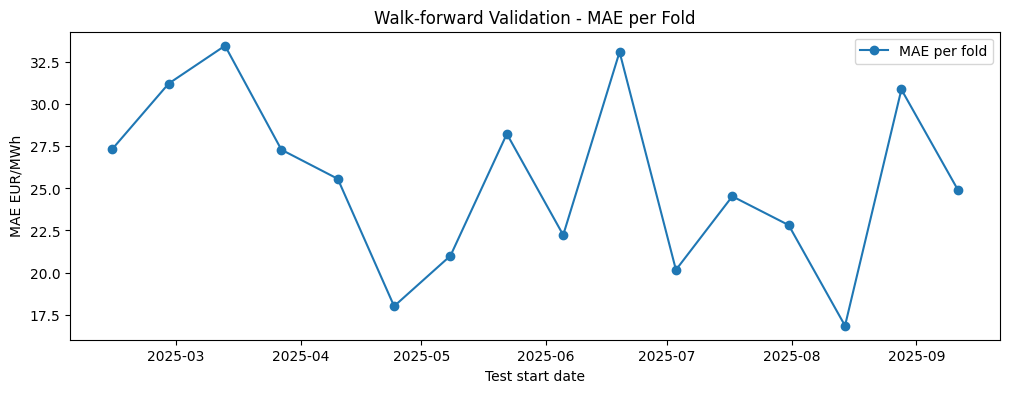

In [11]:
plt.figure(figsize=(12, 4))

plt.plot(
    walk_forward_df["test_start"],
    walk_forward_df["MAE"],
    marker="o",
    label="MAE per fold"
)

plt.title("Walk-forward Validation - MAE per Fold")
plt.xlabel("Test start date")
plt.ylabel("MAE EUR/MWh")
plt.legend()
plt.show()

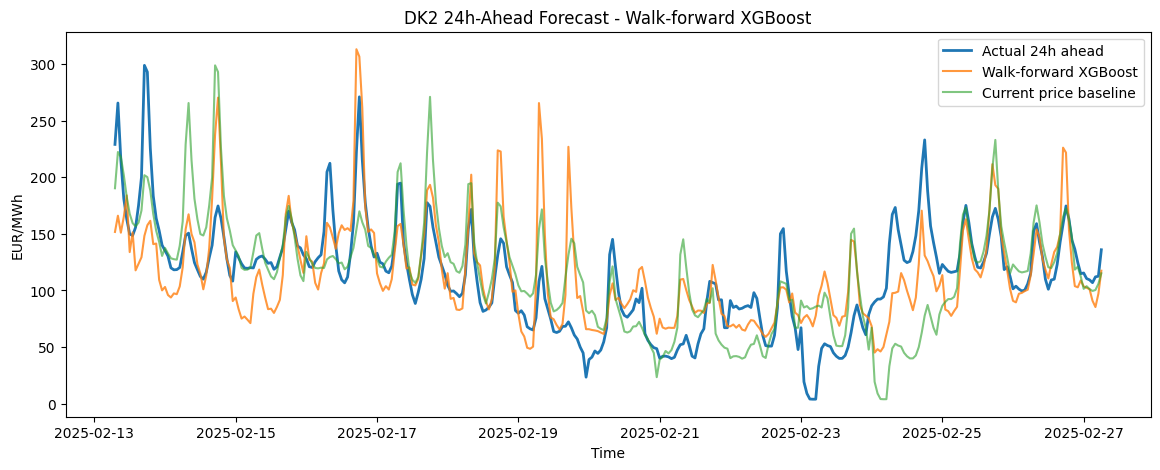

In [12]:
sample = predictions_df.head(336)  # 14 días

plt.figure(figsize=(14, 5))

plt.plot(
    sample["HourDK"],
    sample[target_col],
    label="Actual 24h ahead",
    linewidth=2
)

plt.plot(
    sample["HourDK"],
    sample["pred_xgboost_24h"],
    label="Walk-forward XGBoost",
    alpha=0.8
)

plt.plot(
    sample["HourDK"],
    sample["pred_current_price_baseline"],
    label="Current price baseline",
    alpha=0.6
)

plt.title("DK2 24h-Ahead Forecast - Walk-forward XGBoost")
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.legend()
plt.show()

In [13]:
reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

walk_forward_df.to_csv(
    "../reports/walk_forward_validation_DK2.csv",
    index=False
)

predictions_df.to_csv(
    "../reports/walk_forward_predictions_DK2.csv",
    index=False
)

comparison.to_csv(
    "../reports/walk_forward_model_comparison_DK2.csv",
    index=False
)